In [ ]:
import matplotlib.pyplot as plt
from util.plot_utils import plot_logs
from pathlib import Path

# 绘制损失曲线
plot_logs([Path("training_output_lora/lora_exp2_0105")], 
          fields=('loss', 'loss_bbox', 'loss_ce', 'loss_giou'))
plt.show()

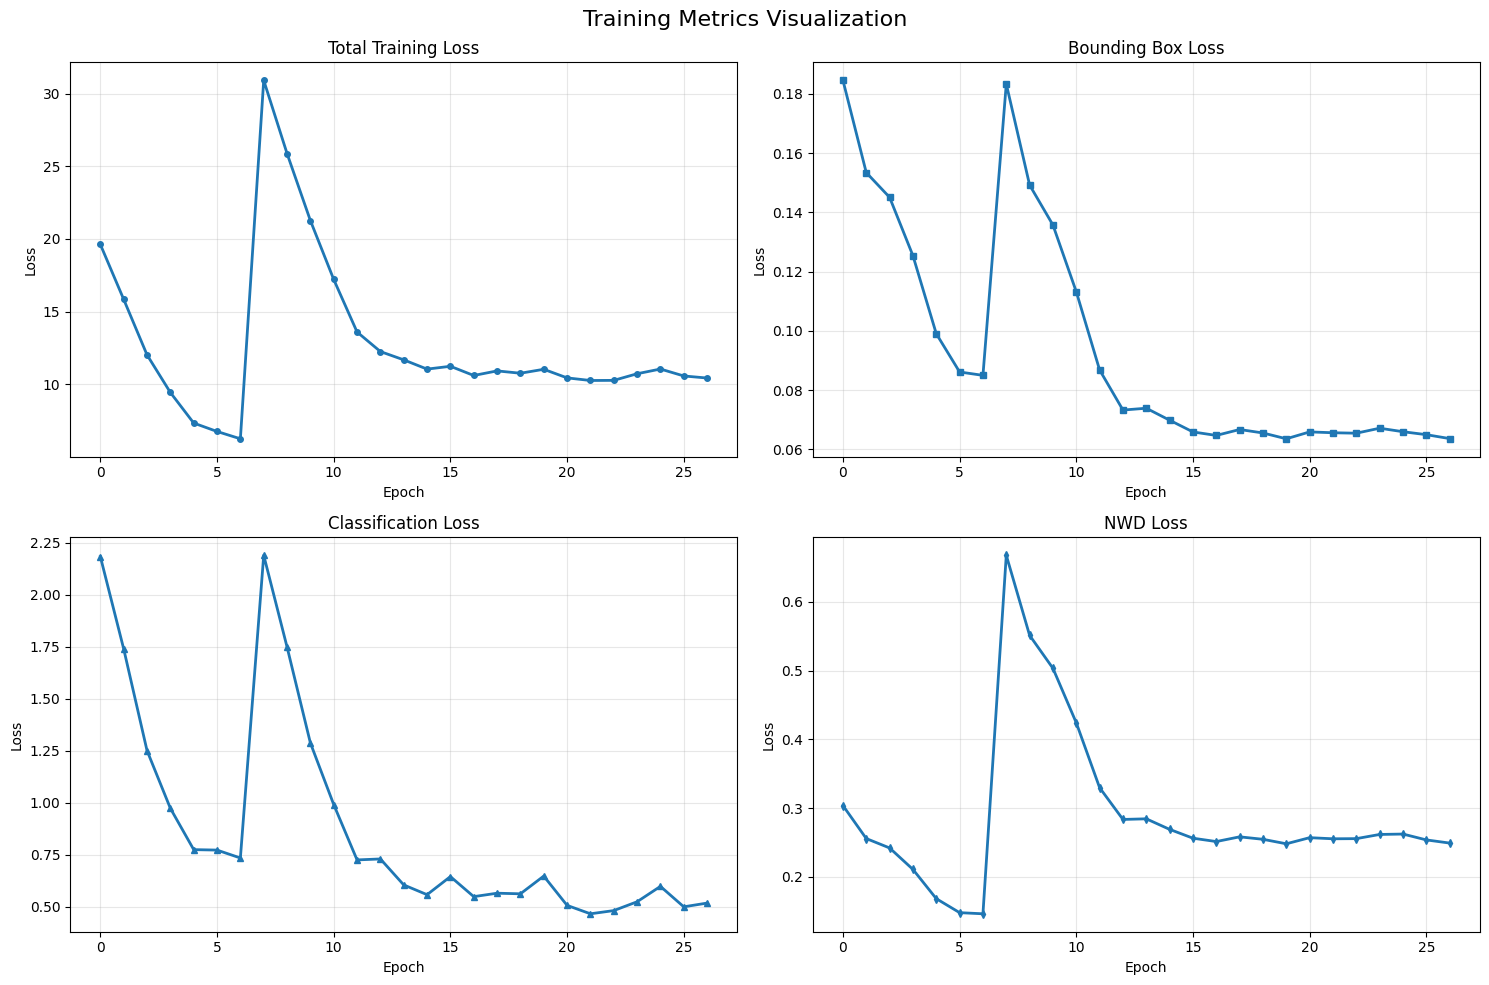

In [6]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 读取训练日志
log_file = "training_output_lora/lora_0106_exp3/log.txt"
data = []
with open(log_file, 'r') as f:
    for line in f:
        data.append(json.loads(line))

# 转换为DataFrame
df = pd.DataFrame(data)

# 创建图表
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Training Metrics Visualization', fontsize=16)

# 总损失
axes[0,0].plot(df['train_loss'], marker='o', linewidth=2, markersize=4)
axes[0,0].set_title('Total Training Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].grid(True, alpha=0.3)

# 边界框损失
axes[0,1].plot(df['train_loss_bbox'], label='BBox Loss', marker='s', linewidth=2, markersize=4)
axes[0,1].set_title('Bounding Box Loss')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].grid(True, alpha=0.3)

# 分类损失
axes[1,0].plot(df['train_loss_ce'], label='Classification Loss', marker='^', linewidth=2, markersize=4)
axes[1,0].set_title('Classification Loss')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].grid(True, alpha=0.3)

# NWD损失
axes[1,1].plot(df['train_loss_nwd'], label='NWD Loss', marker='d', linewidth=2, markersize=4)
axes[1,1].set_title('NWD Loss')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Loss')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

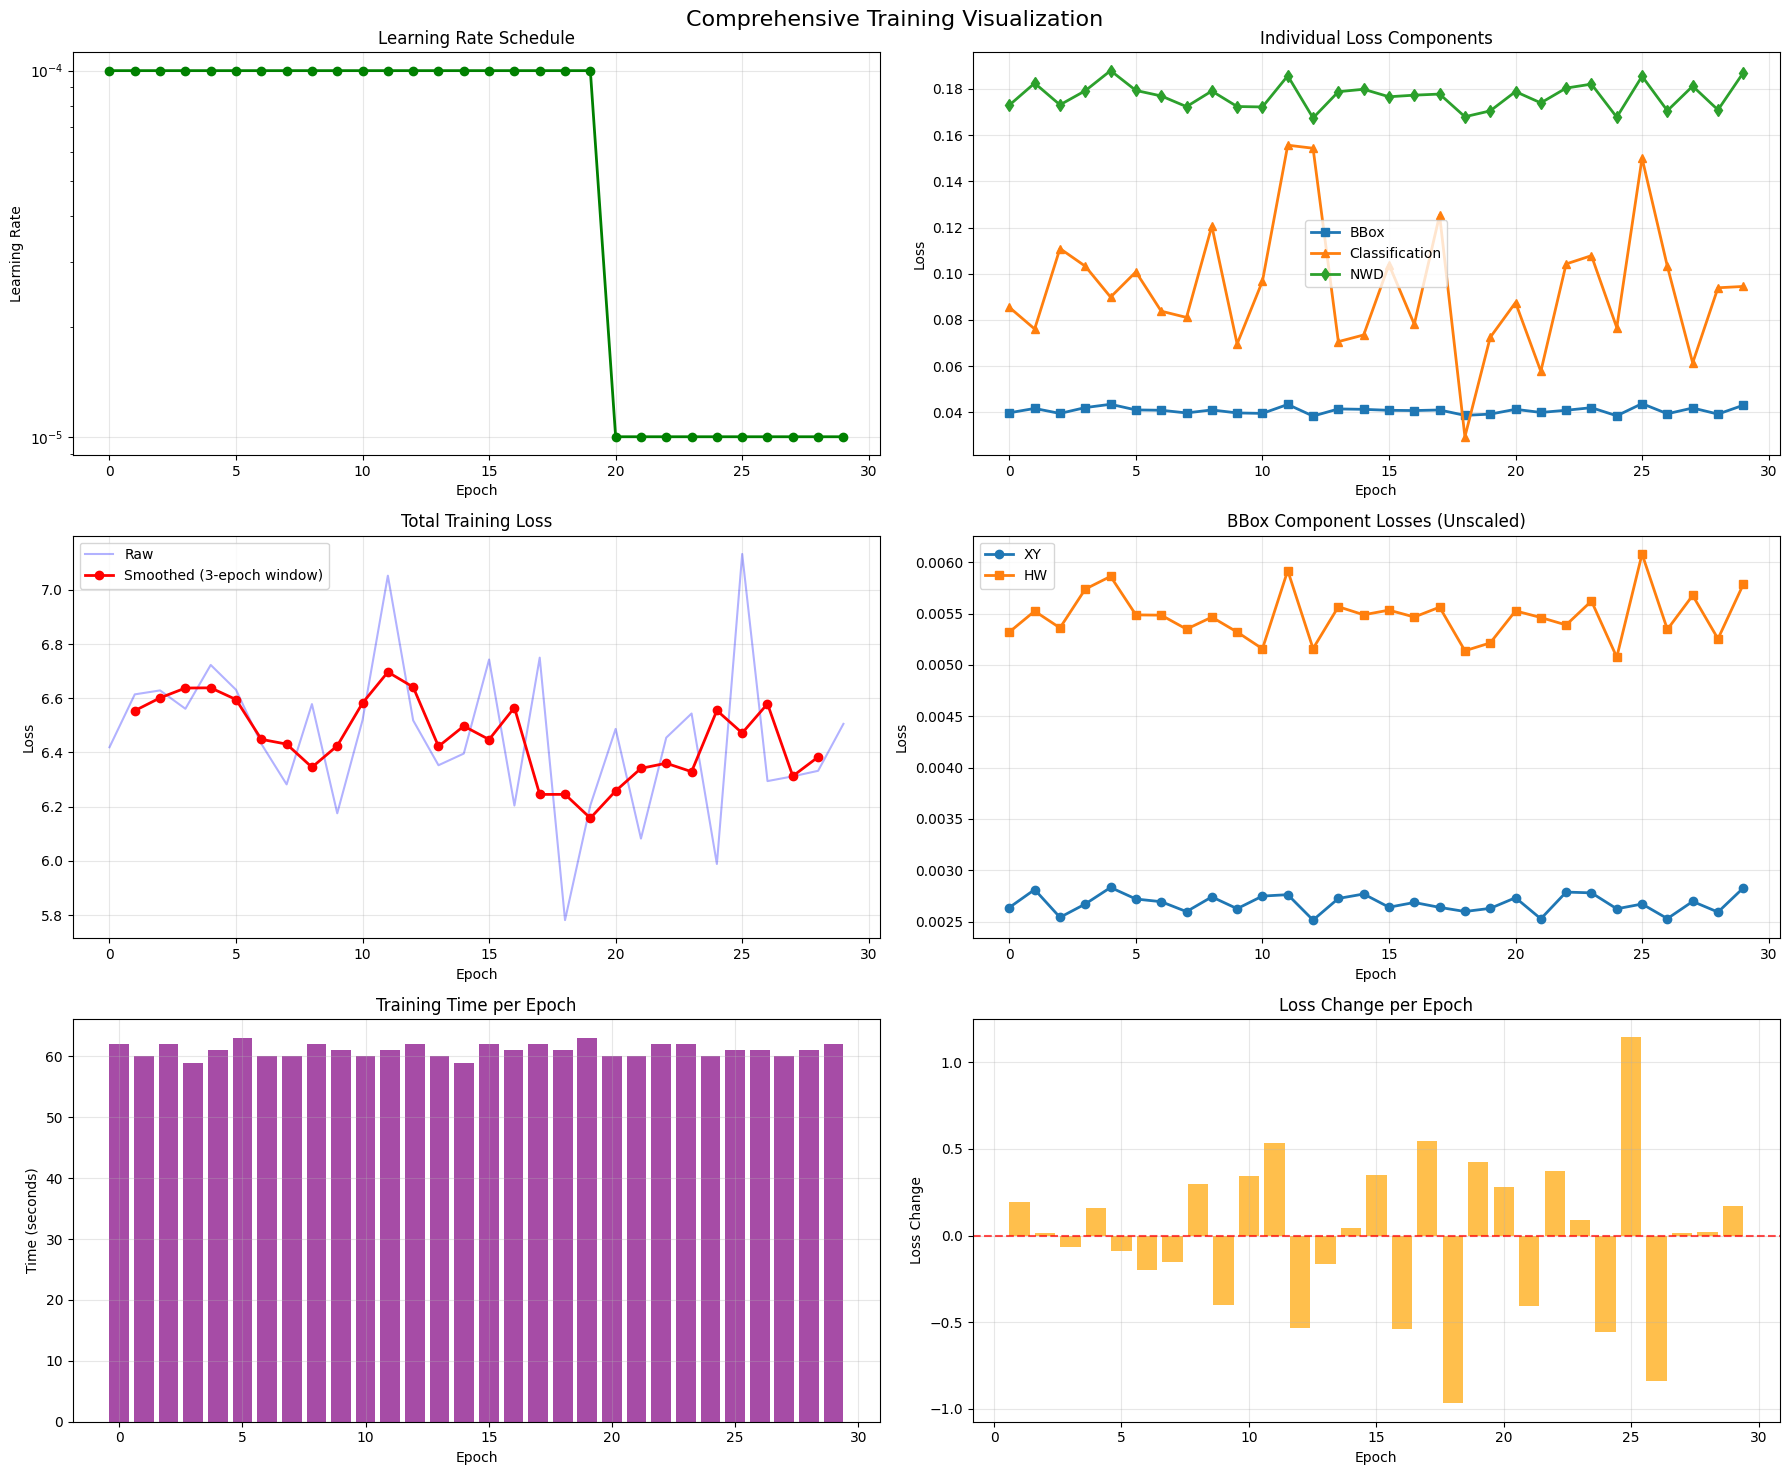

In [5]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 读取训练日志
log_file = "training_output_lora/lora_0121_exp2/log.txt"
data = []
with open(log_file, 'r') as f:
    for line in f:
        data.append(json.loads(line))

# 转换为DataFrame
df = pd.DataFrame(data)

# 创建更详细的可视化
fig, axes = plt.subplots(3, 2, figsize=(18, 15))
fig.suptitle('Comprehensive Training Visualization', fontsize=16)

# 学习率变化
axes[0,0].plot(df['train_lr'], marker='o', color='green', linewidth=2)
axes[0,0].set_title('Learning Rate Schedule')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Learning Rate')
axes[0,0].set_yscale('log')
axes[0,0].grid(True, alpha=0.3)

# 各项损失在同一图中
axes[0,1].plot(df['train_loss_bbox'], label='BBox', marker='s', linewidth=2)
axes[0,1].plot(df['train_loss_ce'], label='Classification', marker='^', linewidth=2)
axes[0,1].plot(df['train_loss_nwd'], label='NWD', marker='d', linewidth=2)
axes[0,1].set_title('Individual Loss Components')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 总损失（带平滑）
window_size = 3
if len(df) >= window_size:
    smoothed_loss = df['train_loss'].rolling(window=window_size, center=True).mean()
    axes[1,0].plot(df['train_loss'], alpha=0.3, color='blue', label='Raw')
    axes[1,0].plot(smoothed_loss, marker='o', color='red', linewidth=2, label=f'Smoothed ({window_size}-epoch window)')
else:
    axes[1,0].plot(df['train_loss'], marker='o', linewidth=2)
axes[1,0].set_title('Total Training Loss')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 边界框各组件损失
axes[1,1].plot(df['train_loss_xy_unscaled'], label='XY', marker='o', linewidth=2)
axes[1,1].plot(df['train_loss_hw_unscaled'], label='HW', marker='s', linewidth=2)
axes[1,1].set_title('BBox Component Losses (Unscaled)')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Loss')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# 训练时间
epoch_times = [pd.Timedelta(t).total_seconds() for t in df['epoch_time']]
axes[2,0].bar(range(len(epoch_times)), epoch_times, alpha=0.7, color='purple')
axes[2,0].set_title('Training Time per Epoch')
axes[2,0].set_xlabel('Epoch')
axes[2,0].set_ylabel('Time (seconds)')
axes[2,0].grid(True, alpha=0.3)

# 损失变化率
loss_changes = df['train_loss'].diff()
axes[2,1].bar(range(len(loss_changes)), loss_changes, alpha=0.7, color='orange')
axes[2,1].axhline(y=0, color='r', linestyle='--', alpha=0.7)
axes[2,1].set_title('Loss Change per Epoch')
axes[2,1].set_xlabel('Epoch')
axes[2,1].set_ylabel('Loss Change')
axes[2,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
import torch
import sys
sys.path.append("/media/sisu/X/hc/projects/Open-GroundingDino")

from groundingdino.util.misc import NestedTensor

# 创建模拟args
class Args:
    backbone = "swin_T_224_1k"
    return_interm_indices = [0, 1, 2, 3]
    use_checkpoint = False
    position_embedding = "sine"
    pe_temperatureH = 20
    pe_temperatureW = 20
    backbone_freeze_keywords = None
    hidden_dim = 256
    # 新增
    use_hr_branch = True
    hr_fusion_type = "add"
    freeze_swin = False

args = Args()

from models.GroundingDINO.backbone.backbone import build_backbone
backbone = build_backbone(args)

# 测试
x = torch.rand(1, 3, 640, 640)
mask = torch.zeros(1, 640, 640).bool()
features, pos = backbone(NestedTensor(x, mask))

print("✓ 测试通过！特征输出：")
for i, f in enumerate(features):
    print(f"  Level {i}: {f.tensors.shape}")

print("\n位置编码输出：")
for i, p in enumerate(pos):
    print(f"  Level {i}: {p.shape}")

[INFO] Using High-Resolution Branch with fusion_type='add'
✓ 测试通过！特征输出：
  Level 0: torch.Size([1, 96, 160, 160])
  Level 1: torch.Size([1, 192, 80, 80])
  Level 2: torch.Size([1, 384, 40, 40])
  Level 3: torch.Size([1, 768, 20, 20])

位置编码输出：
  Level 0: torch.Size([1, 256, 160, 160])
  Level 1: torch.Size([1, 256, 80, 80])
  Level 2: torch.Size([1, 256, 40, 40])
  Level 3: torch.Size([1, 256, 20, 20])
